# Exploratory Data Analysis - Gas Sensor Array Drift

This exploratory analysis examines the Gas Sensor Array Drift Dataset prior to modeling, evaluating data consistency, batch size and class balance variations, feature scale heterogeneity, and the implications of its 16-sensor by 8-descriptor structure. Ultimately, it focuses on the central question of how robustly gas identity can be classified in the face of sensor drift across different acquisition batches.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 140)
pd.set_option("display.width", 160)
RANDOM_STATE = 42


## Load the raw batches

In [2]:
candidate_dirs = [
    Path("data/raw/gas_sensor_array_drift_dataset"),
    Path("../data/raw/gas_sensor_array_drift_dataset"),
]
DATA_DIR = next((p for p in candidate_dirs if p.exists()), None)

if DATA_DIR is None:
    raise FileNotFoundError("Dataset directory not found.")

batch_paths = sorted(
    DATA_DIR.glob("batch*.dat"),
    key=lambda p: int(p.stem.replace("batch", ""))
)

print(f"Dataset directory: {DATA_DIR.resolve()}")
print(f"Batch files found: {len(batch_paths)}")
print([p.name for p in batch_paths])


Dataset directory: /home/adrian/Proyectos/gas-sensor-drift-classification/data/raw/gas_sensor_array_drift_dataset
Batch files found: 10
['batch1.dat', 'batch2.dat', 'batch3.dat', 'batch4.dat', 'batch5.dat', 'batch6.dat', 'batch7.dat', 'batch8.dat', 'batch9.dat', 'batch10.dat']


In [3]:
rows, malformed_rows = [], []

for path in batch_paths:
    batch = int(path.stem.replace("batch", ""))
    with path.open("r", encoding="utf-8") as f:
        for line_number, line in enumerate(f, start=1):
            tokens = line.strip().split()
            if not tokens:
                continue
            try:
                label = int(tokens[0])
                features = {}
                for token in tokens[1:]:
                    idx, value = token.split(":", 1)
                    features[f"feature_{int(idx)}"] = float(value)

                if set(features) != {f"feature_{i}" for i in range(1, 129)}:
                    raise ValueError("Unexpected feature indices")

                rows.append({"label": label, "batch": batch, **features})
            except Exception as exc:
                malformed_rows.append((path.name, line_number, str(exc)))

df = pd.DataFrame(rows)
feature_cols = [f"feature_{i}" for i in range(1, 129)]
X = df[feature_cols]

print(f"Shape: {df.shape}")
print(f"Malformed rows: {len(malformed_rows)}")
df.head()


Shape: (13910, 130)
Malformed rows: 0


,label,batch,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30,feature_31,feature_32,feature_33,feature_34,feature_35,feature_36,feature_37,feature_38,feature_39,feature_40,feature_41,feature_42,feature_43,feature_44,feature_45,feature_46,feature_47,feature_48,feature_49,feature_50,feature_51,feature_52,feature_53,feature_54,feature_55,feature_56,feature_57,feature_58,feature_59,feature_60,feature_61,feature_62,feature_63,feature_64,feature_65,feature_66,feature_67,feature_68,feature_69,feature_70,feature_71,feature_72,feature_73,feature_74,feature_75,feature_76,feature_77,feature_78,feature_79,feature_80,feature_81,feature_82,feature_83,feature_84,feature_85,feature_86,feature_87,feature_88,feature_89,feature_90,feature_91,feature_92,feature_93,feature_94,feature_95,feature_96,feature_97,feature_98,feature_99,feature_100,feature_101,feature_102,feature_103,feature_104,feature_105,feature_106,feature_107,feature_108,feature_109,feature_110,feature_111,feature_112,feature_113,feature_114,feature_115,feature_116,feature_117,feature_118,feature_119,feature_120,feature_121,feature_122,feature_123,feature_124,feature_125,feature_126,feature_127,feature_128
0,1,1,15596.1621,1.868245,2.371604,2.803678,7.512213,-2.739388,-3.344671,-4.847512,15326.6914,1.768526,2.269085,2.713374,6.915721,-2.488324,-3.082212,-5.056975,2789.3831,2.754759,0.430440,0.649457,1.795029,-0.426662,-0.584313,-1.438976,2581.5686,2.680623,0.399746,0.605065,1.786704,-0.400115,-0.550743,-1.728611,685.3994,1.682904,0.122736,0.223703,0.584691,-0.138196,-0.236907,-0.781959,797.7738,1.742488,0.152483,0.218904,0.841862,-0.164646,-0.315720,-0.791447,3128.8489,3.605537,0.532422,0.763062,2.118983,-0.557197,-0.809953,-2.344130,3136.8778,3.555169,0.535883,0.761388,1.499244,-0.571480,-0.944425,-2.658358,13540.6738,1.765738,2.006883,2.519022,6.261430,-2.172101,-2.694967,-3.791499,13831.7539,1.746493,2.057165,2.391239,5.695234,-2.350776,-2.888766,-8.129869,3020.9191,2.819354,0.474520,0.723993,2.160130,-0.467900,-0.638167,-1.643650,2185.9741,2.949381,0.342575,0.515090,1.340477,-0.361030,-0.493482,-1.200617,862.7479,1.779291,0.165138,0.246473,1.358106,-0.187465,-0.416382,-1.058061,1059.7562,1.896047,0.198946,0.334017,0.815048,-0.204467,-0.345119,-0.969336,3357.1124,3.860647,0.580818,0.806830,1.729739,-0.619214,-1.071137,-3.037772,3037.0390,3.972203,0.527291,0.728443,1.445783,-0.545079,-0.902241,-2.654529
1,1,1,26402.0704,2.532401,5.411209,6.509906,7.658469,-4.722217,-5.817651,-7.518333,23855.7812,2.164706,4.901063,5.971392,6.978131,-4.199424,-5.221090,-7.604863,3882.9057,3.155054,0.802987,1.172245,1.570895,-0.697881,-0.944655,-1.334743,3651.0427,3.130669,0.739278,1.101765,1.428631,-0.659641,-0.915543,-1.334217,982.9490,1.933877,0.233308,0.378052,0.717916,-0.225572,-0.354591,-0.748061,1162.2378,2.039431,0.278337,0.486908,0.840494,-0.271369,-0.473164,-0.718214,4332.1543,3.990162,1.002503,1.586233,1.926608,-0.913245,-1.335612,-1.773328,4387.5284,4.011519,1.009769,1.647830,1.962858,-0.944028,-1.631468,-1.925095,20553.5645,2.108870,4.266941,5.185937,6.398693,-3.636176,-4.497039,-7.464548,22540.1933,2.222146,4.621283,5.573620,6.756039,-3.986434,-4.953663,-6.561748,4240.3011,3.262893,0.887237,1.297617,1.630074,-0.768036,-1.244472,-1.419646,3079.0621,3.399659,0.649639,0.948781,1.369550,-0.598444,-0.820868,-1.081919,1237.0131,2.067927,0.305793,0.558008,0.948564,-0.289557,-0.501078,-1.191404,1459.6356,2.149242,0.361007,0.614619,0.950204,-0.327339,-0.503861,-0.838039,4685.7753,4.277604,1.080629,1.818559,2.237534,-1.004812,-1.530519,-1.994993,4176.4453,4.281373,0.980205,1.628050,1.951172,-0.889333,-1.323505,-1.749225
2,1,1,42103.5820,3.454189,8.198175,10.508439,11.611003,-7.668313,-9.478675,-12.230939,37562.3008,2.840403,7.386

## Structural and data-quality checks

Expected structure: 13,910 observations, 128 features (16 sensors x 8 descriptors), 6 classes and 10 batches (https://archive-beta.ics.uci.edu/dataset/224/gas%2Bsensor%2Barray%2Bdrift%2Bdataset?utm_source=chatgpt.com).


In [4]:
summary = pd.DataFrame({
    "expected": [13910, 128, 6, 10],
    "observed": [
        len(df),
        len(feature_cols),
        df["label"].nunique(),
        df["batch"].nunique(),
    ],
}, index=["rows", "features", "classes", "batches"])
summary


,expected,observed
rows,13910,13910
features,128,128
classes,6,6
batches,10,10


In [5]:
quality = pd.Series({
    "missing_values": int(X.isna().sum().sum()),
    "infinite_values": int(np.isinf(X.to_numpy()).sum()),
    "exact_duplicate_rows": int(df.duplicated().sum()),
    "duplicate_feature_vectors": int(df.duplicated(subset=feature_cols).sum()),
    "constant_features": int(sum(X[col].nunique(dropna=False) <= 1 for col in feature_cols)),
})
quality


missing_values               0
infinite_values              0
exact_duplicate_rows         0
duplicate_feature_vectors    0
constant_features            0
dtype: int64

## Batch sizes and global class balance

In [6]:
batch_sizes = df.groupby("batch").size()
pd.DataFrame({
    "n": batch_sizes,
    "percent": (100 * batch_sizes / len(df)).round(2),
})


,n,percent
batch,,
1,445,3.20
2,1244,8.94
3,1586,11.40
4,161,1.16
5,197,1.42
6,2300,16.53
7,3613,25.97
8,294,2.11
9,470,3.38


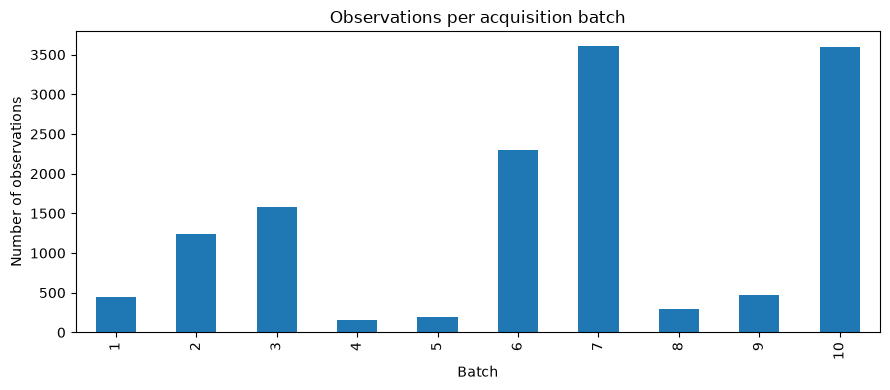

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
batch_sizes.plot(kind="bar", ax=ax)
ax.set_title("Observations per acquisition batch")
ax.set_xlabel("Batch")
ax.set_ylabel("Number of observations")
plt.tight_layout()
plt.show()


In [8]:
class_counts = df["label"].value_counts().sort_index()
pd.DataFrame({
    "n": class_counts,
    "percent": (100 * class_counts / len(df)).round(2),
})


,n,percent
label,,
1,2565,18.44
2,2926,21.04
3,1641,11.80
4,1936,13.92
5,3009,21.63
6,1833,13.18


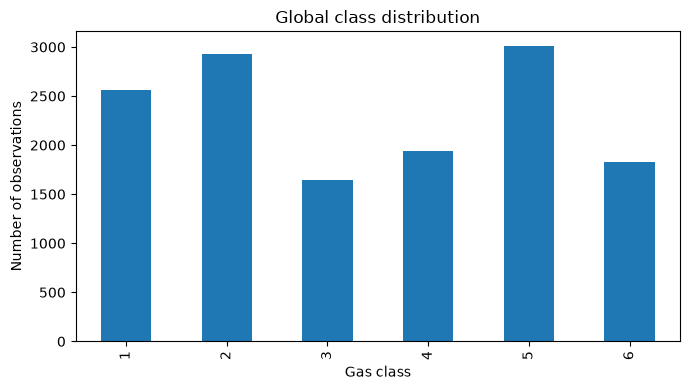

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
class_counts.plot(kind="bar", ax=ax)
ax.set_title("Global class distribution")
ax.set_xlabel("Gas class")
ax.set_ylabel("Number of observations")
plt.tight_layout()
plt.show()


Both the classes and, particularly, the batches are heavily imbalanced. Let's look at the class distribution broken down by batch.

## Class distribution across batches

In [10]:
batch_class_counts = pd.crosstab(df["batch"], df["label"])
batch_class_pct = pd.crosstab(df["batch"], df["label"], normalize="index") * 100

display(batch_class_counts)
display(batch_class_pct.round(1))


label,1,2,3,4,5,6
batch,,,,,,
1,90,98,83,30,70,74
2,164,334,100,109,532,5
3,365,490,216,240,275,0
4,64,43,12,30,12,0
5,28,40,20,46,63,0
6,514,574,110,29,606,467
7,649,662,360,744,630,568
8,30,30,40,33,143,18
9,61,55,100,75,78,101


label,1,2,3,4,5,6
batch,,,,,,
1,20.2,22.0,18.7,6.7,15.7,16.6
2,13.2,26.8,8.0,8.8,42.8,0.4
3,23.0,30.9,13.6,15.1,17.3,0.0
4,39.8,26.7,7.5,18.6,7.5,0.0
5,14.2,20.3,10.2,23.4,32.0,0.0
6,22.3,25.0,4.8,1.3,26.3,20.3
7,18.0,18.3,10.0,20.6,17.4,15.7
8,10.2,10.2,13.6,11.2,48.6,6.1
9,13.0,11.7,21.3,16.0,16.6,21.5


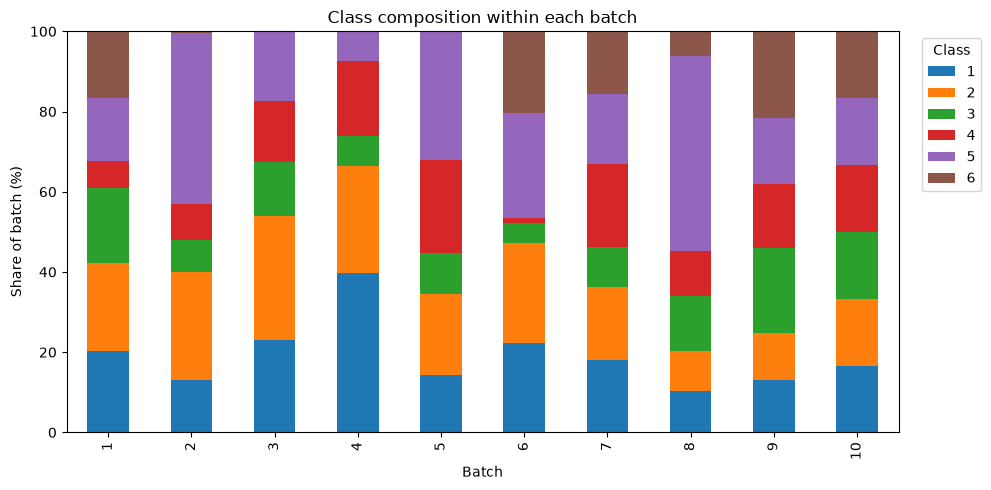

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
batch_class_pct.plot(kind="bar", stacked=True, ax=ax)
ax.set_title("Class composition within each batch")
ax.set_xlabel("Batch")
ax.set_ylabel("Share of batch (%)")
ax.legend(title="Class", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [12]:
missing_pairs = [
    (batch, label)
    for batch in sorted(df["batch"].unique())
    for label in sorted(df["label"].unique())
    if ((df["batch"] == batch) & (df["label"] == label)).sum() == 0
]
print("Missing batch/class combinations:", missing_pairs)


Missing batch/class combinations: [(np.int64(3), np.int64(6)), (np.int64(4), np.int64(6)), (np.int64(5), np.int64(6))]


Individual batches are highly imbalanced or even miss classes entirely. This matters because random splitting can hide deployment-time distribution changes. A batch-aware evaluation is therefore not equivalent to ordinary stratified cross-validation.

## Feature scales and sensor structure

In [13]:
feature_stats = X.agg(["min", "max", "mean", "std"]).T
print("Std scale ratio:", feature_stats["std"].max() / feature_stats["std"].min())
display(feature_stats.nsmallest(8, "std")[["std", "min", "max"]])
display(feature_stats.nlargest(8, "std")[["std", "min", "max"]])


Std scale ratio: 132116.52755226378


,std,min,max
feature_46,0.528660,-3.878568,-0.005127
feature_38,0.599533,-12.562238,-0.003572
feature_110,0.688228,-3.804284,-0.007898
feature_102,0.702420,-4.240221,-0.002425
feature_43,0.724779,0.002058,22.108175
feature_35,0.812730,0.003074,19.809417
feature_47,0.914784,-41.210308,1.632964
feature_107,0.979695,0.001948,5.997730


,std,min,max
feature_1,69844.785952,-16757.5986,670687.3477
feature_9,64045.265134,-16119.4609,502202.8125
feature_65,51386.395589,-4441.2929,463858.1210
feature_73,47349.945833,-3487.9385,490020.0234
feature_113,16603.686992,-9231.1191,113301.9158
feature_121,14281.652395,-8297.5488,96706.7927
feature_57,13840.867682,-18973.4063,86587.8154
feature_81,13509.725928,-9959.8164,87508.1494


In [14]:
sensor_groups = {
    sensor: [f"feature_{i}" for i in range((sensor - 1) * 8 + 1, sensor * 8 + 1)]
    for sensor in range(1, 17)
}

position_stats = []
for position in range(1, 9):
    cols = [f"feature_{(sensor - 1) * 8 + position}" for sensor in range(1, 17)]
    values = X[cols].to_numpy().ravel()
    position_stats.append({
        "descriptor_position": position,
        "mean_abs": np.mean(np.abs(values)),
        "median_abs": np.median(np.abs(values)),
        "std": np.std(values),
        "min": np.min(values),
        "max": np.max(values),
    })

pd.DataFrame(position_stats).round(3)


,descriptor_position,mean_abs,median_abs,std,min,max
0,1,22328.268,11415.052,35014.051,-23660.635,670687.348
1,2,5.453,3.749,76.768,0.088,31165.170
2,3,6.732,3.470,9.270,0.000,169.248
3,4,11.980,6.537,14.937,0.000,730.924
4,5,16.946,9.803,36.105,0.000,12005.619
5,6,4.551,2.286,6.430,-131.333,0.000
6,7,7.271,3.560,11.127,-406.576,22.202
7,8,22.853,8.565,67.979,-2946.482,116.506


The 128 columns naturally form 16 sensors × 8 descriptors. The extracted sensor descriptors differ substantially in numerical scale (specially descriptor 0), with feature standard deviations spanning more than five orders of magnitude. Therefore, scale-sensitive models should be evaluated using standardized features.

## Extreme values

In [15]:
means = X.mean()
stds = X.std().replace(0, np.nan)
z = ((X - means) / stds).abs()

pd.DataFrame({
    "threshold": [5, 10, 20],
    "n_values": [int((z > t).sum().sum()) for t in [5, 10, 20]],
    "n_features": [int((z > t).any(axis=0).sum()) for t in [5, 10, 20]],
})


,threshold,n_values,n_features
0,5,4527,113
1,10,345,67
2,20,69,39


In [16]:
extreme_counts = (z > 10).sum().sort_values(ascending=False)
extreme_counts[extreme_counts > 0].head(15)


feature_64     23
feature_56     21
feature_96     21
feature_120    20
feature_88     18
feature_128    17
feature_24     15
feature_13     13
feature_16     12
feature_74     11
feature_104    11
feature_112     9
feature_28      9
feature_5       9
feature_8       9
dtype: int64

These are diagnostic counts only. A large z-score is not evidence by itself that a chemical-sensor measurement is erroneous.

## Feature redundancy

In [17]:
corr = X.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

pd.Series({
    "|r| > 0.90": int((upper > 0.90).sum().sum()),
    "|r| > 0.95": int((upper > 0.95).sum().sum()),
    "|r| > 0.99": int((upper > 0.99).sum().sum()),
})


|r| > 0.90    547
|r| > 0.95    246
|r| > 0.99     30
dtype: int64

In [18]:
top_corr = (
    upper.stack()
    .sort_values(ascending=False)
    .head(15)
    .rename("abs_correlation")
    .reset_index()
)
top_corr.columns = ["feature_a", "feature_b", "abs_correlation"]
top_corr


,feature_a,feature_b,abs_correlation
0,feature_42,feature_58,0.999649
1,feature_50,feature_58,0.999535
2,feature_114,feature_122,0.999128
3,feature_54,feature_62,0.998959
4,feature_49,feature_57,0.998929
5,feature_118,feature_126,0.998846
6,feature_42,feature_50,0.998388
7,feature_115,feature_123,0.998256
8,feature_113,feature_121,0.998177
9,feature_51,feature_59,0.998082


High correlation is not automatically a reason to remove variables, but it must be considered when interpreting coefficients and feature importance.

## Descriptive shift across batches

We compute a simple descriptive shift score by comparing each feature’s mean in a given batch with its mean in batch 1, normalized by that feature’s standard deviation to account for differences in scale, and then averaging across all 128 features. Higher values indicate greater changes in sensor responses relative to batch 1. This is only an exploratory indicator, not a formal drift metric, as it captures changes in feature means but not other distributional changes and may also reflect differences in class composition or experimental conditions between batches.


In [19]:
global_std = X.std().replace(0, np.nan)
batch_means = df.groupby("batch")[feature_cols].mean()
reference_mean = batch_means.loc[1]

overall_shift = []
for batch, mean_values in batch_means.iterrows():
    shift = ((mean_values - reference_mean) / global_std).abs()
    overall_shift.append({
        "batch": batch,
        "mean_shift": shift.mean(),
        "median_shift": shift.median(),
        "max_shift": shift.max(),
    })

overall_shift = pd.DataFrame(overall_shift)
overall_shift.round(3)


,batch,mean_shift,median_shift,max_shift
0,1,0.000,0.000,0.000
1,2,0.357,0.361,0.929
2,3,0.674,0.701,1.387
3,4,0.995,0.871,3.320
4,5,0.794,0.845,2.102
5,6,0.501,0.433,1.637
6,7,0.524,0.477,1.626
7,8,0.554,0.408,1.842
8,9,0.591,0.502,1.910
9,10,0.348,0.240,1.393


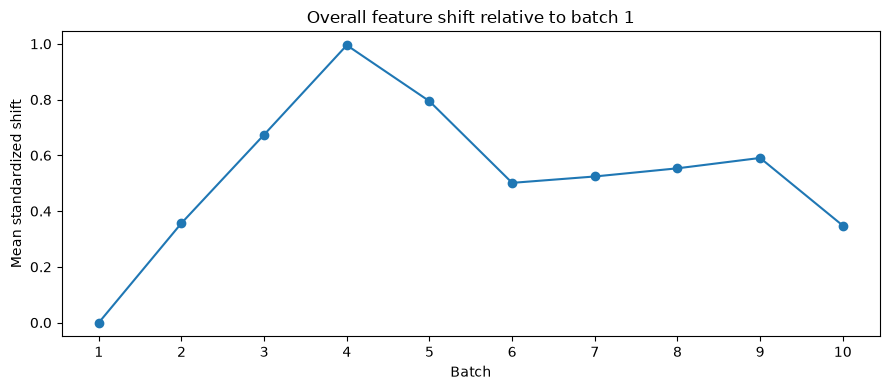

In [20]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(overall_shift["batch"], overall_shift["mean_shift"], marker="o")
ax.set_title("Overall feature shift relative to batch 1")
ax.set_xlabel("Batch")
ax.set_ylabel("Mean standardized shift")
ax.set_xticks(overall_shift["batch"])
plt.tight_layout()
plt.show()


Overall shift can be confounded by changing class proportions. To reduce that confounding, the comparison is repeated within each gas class.

In [21]:
within_class_rows = []

for label in sorted(df["label"].unique()):
    class_df = df[df["label"] == label]
    class_std = class_df[feature_cols].std().replace(0, np.nan)
    means_by_batch = class_df.groupby("batch")[feature_cols].mean()

    reference_batch = means_by_batch.index.min()
    reference = means_by_batch.loc[reference_batch]

    for batch, mean_values in means_by_batch.iterrows():
        shift = ((mean_values - reference) / class_std).abs()
        within_class_rows.append({
            "label": label,
            "reference_batch": reference_batch,
            "batch": batch,
            "mean_shift": shift.mean(),
            "median_shift": shift.median(),
        })

within_class_shift = pd.DataFrame(within_class_rows)
within_class_pivot = within_class_shift.pivot(
    index="batch", columns="label", values="mean_shift"
)
within_class_pivot.round(2)


label,1,2,3,4,5,6
batch,,,,,,
1,0.00,0.00,0.00,0.00,0.00,0.00
2,0.45,0.35,0.48,1.62,0.55,0.59
3,0.96,0.78,0.70,1.65,0.65,NaN
4,1.41,0.73,0.56,2.22,1.05,NaN
5,1.30,0.81,0.64,2.32,1.05,NaN
6,0.69,0.48,0.59,2.18,0.84,1.60
7,0.76,0.58,0.76,1.81,0.86,1.72
8,0.91,0.70,0.74,1.86,0.95,1.66
9,0.84,0.75,0.83,1.81,0.91,1.99


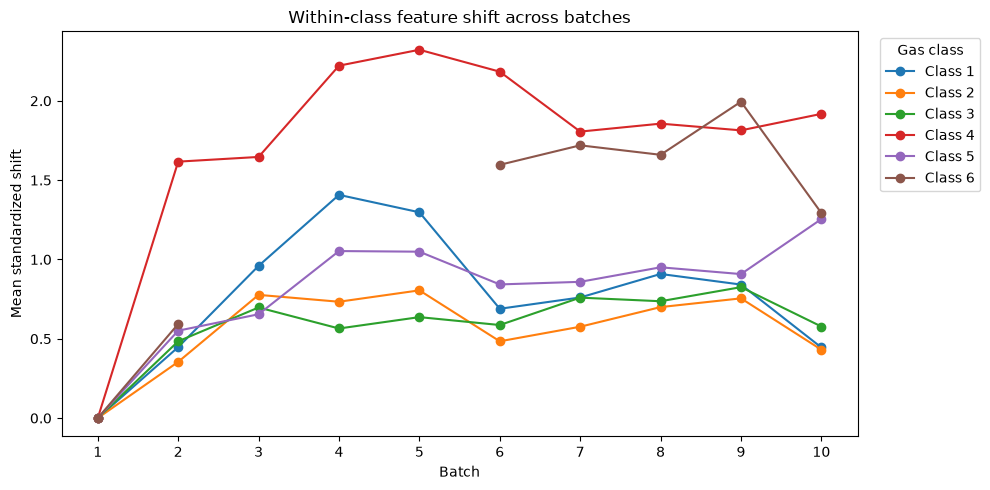

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))
for label in within_class_pivot.columns:
    ax.plot(
        within_class_pivot.index,
        within_class_pivot[label],
        marker="o",
        label=f"Class {label}",
    )

ax.set_title("Within-class feature shift across batches")
ax.set_xlabel("Batch")
ax.set_ylabel("Mean standardized shift")
ax.set_xticks(sorted(df["batch"].unique()))
ax.legend(title="Gas class", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


The feature distributions show substantial and non-monotonic changes across acquisition batches. Importantly, these shifts remain visible when conditioning on gas class, suggesting that changes in batch composition alone do not explain the observed distribution shift. The magnitude of the shift also varies considerably between gas classes, supporting the use of batch-aware evaluation to assess model robustness over time.

## Sensor-level descriptive shift

This analysis compares the response of each sensor between batches 1 and 10. For each sensor, the mean change of its eight features is standardized by their respective standard deviations, making features with different scales comparable. Higher values indicate greater changes in that sensor’s response features. Since the analysis does not control for gas class or other experimental conditions, it should be interpreted as a descriptive comparison rather than a direct measure of sensor drift.

In [23]:
sensor_shift_rows = []

for sensor, cols in sensor_groups.items():
    sensor_std = X[cols].std().replace(0, np.nan)
    mean_1 = df.loc[df["batch"] == 1, cols].mean()
    mean_10 = df.loc[df["batch"] == 10, cols].mean()
    shift = ((mean_10 - mean_1) / sensor_std).abs()

    sensor_shift_rows.append({
        "sensor": sensor,
        "mean_shift_batch1_to_10": shift.mean(),
        "median_shift_batch1_to_10": shift.median(),
        "max_shift_batch1_to_10": shift.max(),
    })

sensor_shift_df = pd.DataFrame(sensor_shift_rows)
sensor_shift_df.sort_values("mean_shift_batch1_to_10", ascending=False).round(3)


,sensor,mean_shift_batch1_to_10,median_shift_batch1_to_10,max_shift_batch1_to_10
9,10,0.819,0.930,1.393
0,1,0.688,0.819,1.180
8,9,0.609,0.598,1.112
1,2,0.481,0.512,0.851
5,6,0.339,0.401,0.640
15,16,0.310,0.253,0.614
12,13,0.309,0.244,0.809
4,5,0.307,0.223,0.640
13,14,0.290,0.225,0.676
14,15,0.285,0.221,0.601


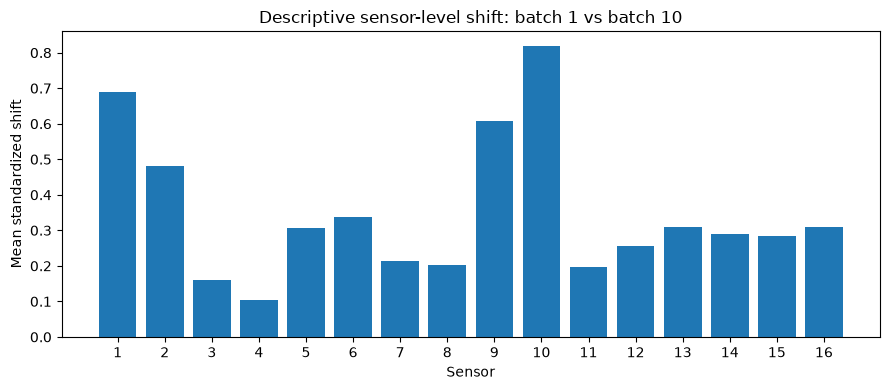

In [24]:
plot_df = sensor_shift_df.sort_values("sensor")
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(plot_df["sensor"], plot_df["mean_shift_batch1_to_10"])
ax.set_title("Descriptive sensor-level shift: batch 1 vs batch 10")
ax.set_xlabel("Sensor")
ax.set_ylabel("Mean standardized shift")
ax.set_xticks(range(1, 17))
plt.tight_layout()
plt.show()


The magnitude of the observed shift varies considerably across sensors. This suggests that distribution changes are not uniform across the sensor array, although these differences should not be interpreted as direct measurements of sensor drift.

## PCA projection

PCA is exploratory only, allowing us to visually inspect whether samples exhibit structure related to gas class or acquisition batch. It is fitted on standardized features so that high-magnitude descriptors do not dominate the projection.

In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "label": df["label"].to_numpy(),
    "batch": df["batch"].to_numpy(),
})

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained:", pca.explained_variance_ratio_.sum())


Explained variance ratio: [0.53515135 0.15040059]
Total explained: 0.685551939368467


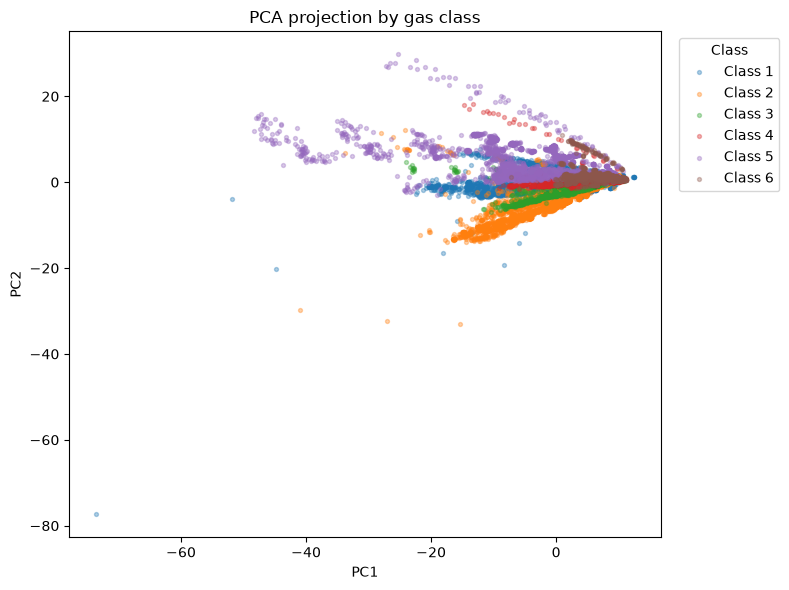

In [29]:
fig, ax = plt.subplots(figsize=(8, 6))
for label in sorted(pca_df["label"].unique()):
    part = pca_df[pca_df["label"] == label]
    ax.scatter(part["PC1"], part["PC2"], s=8, alpha=0.35, label=f"Class {label}")
ax.set_title("PCA projection by gas class")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend(title="Class", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


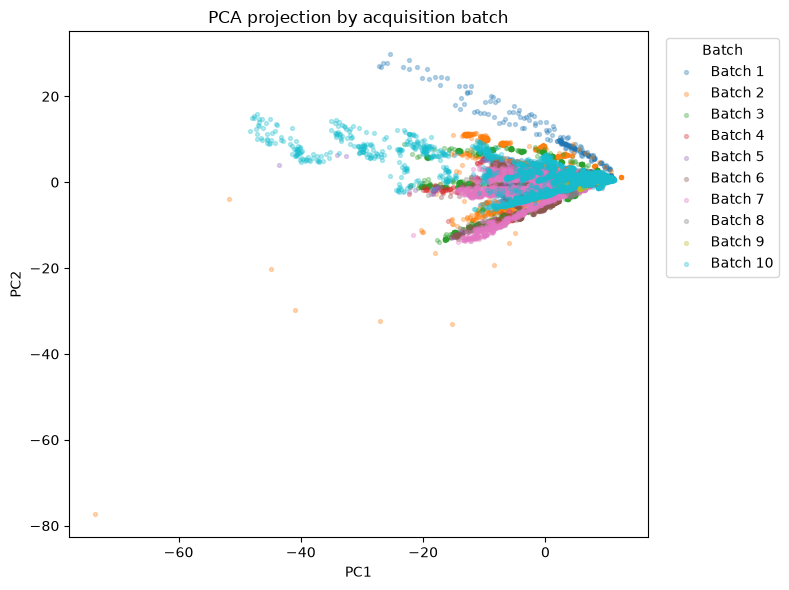

In [30]:
fig, ax = plt.subplots(figsize=(8, 6))
for batch in sorted(pca_df["batch"].unique()):
    part = pca_df[pca_df["batch"] == batch]
    ax.scatter(part["PC1"], part["PC2"], s=8, alpha=0.30, label=f"Batch {batch}")
ax.set_title("PCA projection by acquisition batch")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend(title="Batch", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


The PCA projections reveal structure associated with both gas class and acquisition batch. Gas classes occupy partially distinct but overlapping regions, while several batches show visibly different distributions in the projected space. This provides additional qualitative evidence of batch-dependent distribution shift, although the substantial overlap and dimensionality reduction mean that PCA alone cannot establish either class separability or sensor drift.

## EDA conclusions

The modelling stage should be based on these observations:

- The raw dataset is structurally clean.
- Batch sizes differ substantially.
- Class proportions vary strongly across batches and some classes are absent in specific batches.
- Feature distributions shift across batches even within the same class.
- Feature scales differ by orders of magnitude.
- Many features are strongly correlated.
- The 128 features have a meaningful sensor grouping: 16 sensors × 8 descriptors.
- Extreme values should be investigated, not automatically removed.
